![](https://raw.githubusercontent.com/EcoCommons-Australia-2024-2026/ec-notebook_site/main/images/notebooks_banner_withframe.png)

# Converting Rasters from ASCII (.asc) to GeoTIFF (.tif) Format

Author details: Dr Ryan Newis

Editor details: Xiang Zhao

Contact details: support\@ecocommons.org.au

Copyright statement: This script is the product of the EcoCommons platform. Please refer to the EcoCommons website for more details: <https://www.ecocommons.org.au/>

Date: Feb 2026

# Script and Data Information

This notebook provides a simple, reproducible example of converting an ASCII grid (.asc) to a GeoTIFF raster format using the `terra` package in R. It is intended as a lightweight template that can be adapted to other ASCII-based spatial datasets and workflows.

# Introduction

ASCII grid files remain a common format for distributing spatial data, particularly in legacy systems and environmental modelling contexts. However, many modern spatial analysis workflows in R are more efficient when working with native raster formats such as GeoTIFF.

Although format conversion is often treated as a straightforward technical step, preserving spatial metadata during this process is essential. Changes to the coordinate reference system (CRS), spatial extent, or grid resolution can introduce subtle spatial misalignment that may not be immediately visible but can affect downstream analyses and modelling results.

This notebook demonstrates a structured and transparent approach to converting an ASCII grid to a GeoTIFF format while explicitly verifying that key spatial properties including CRS, extent, and resolution are maintained. By incorporating validation steps into the workflow, the notebook promotes reproducibility and safeguards spatial data integrity.

# Key Concepts

## K.1 ASCII grid data formats

ASCII grids (.asc) are text-based raster formats that store spatial data alongside header information describing extent, resolution, and coordinate reference systems. While widely supported, they are often less efficient than binary raster formats.

## K.2 Raster data handling in R with `terra`

The `terra` package provides a modern framework for reading, manipulating, and writing raster data in R. It supports a wide range of raster formats and is designed for performance, clarity, and reproducibility.

## K.3 Converting between raster formats

Converting raster data between formats (e.g. ASCII → GeoTIFF) is a common preprocessing step that enables compatibility with modern analysis tools. A robust conversion workflow should ensure that key spatial properties including CRS, extent, and resolution are preserved.

# Notebook Objectives

1.  Demonstrate how to read an ASCII grid file (.asc) into R as a SpatRaster using the `terra` package.
2.  Perform a basic visual check (plot) to confirm that the raster has been converted and loaded correctly.
3.  Save the raster to a modern file format (.tif) while preserving the original file naming.
4.  Verify that key spatial metadata (CRS, extent, and resolution) are preserved during the conversion process.

# Workflow Overview

This notebook follows a simple, linear workflow to convert an ASCII grid to a GeoTIFF format via the steps below:

-   Step 1: Set up the R environment and load the required package (`terra`).
-   Step 2: Define and validate the file path to the input ASCII (.asc) grid.
-   Step 3: Read the ASCII grid into R as a SpatRaster object and confirm that a valid CRS is defined.
-   Step 4: Perform a quick visual check by plotting the raster to confirm it was read correctly.
-   Step 5: Write the raster to disk as a GeoTIFF (.tif) file, preserving the original file name and providing a transparent output location.
-   Step 6: Validate that CRS, spatial extent, and resolution are preserved after conversion.

In the near future, this material may form part of comprehensive support materials available to EcoCommons users. If you have any corrections or suggestions to improve the efficiency, please [contact the EcoCommons](mailto:support@ecocommons.org.au) team.

![](https://raw.githubusercontent.com/EcoCommons-Australia-2024-2026/ec-notebook_site/main/images/EC_breaker_nobackgoundcolor.png)

# Step 1. Install and load required packages

Install and load R packages and libraries that are not present in the work environment. For this notebook, we only require the `terra` package for the ASCII (.asc) to GeoTIFF (.tif) conversion and `googledrive` to download the example ASCII file.


In [1]:

# Install and load required packages (if not already installed)
required_packages <- c(
  "terra",
  "googledrive"
)

for (pkg in required_packages) {

  # Install if missing
  if (!pkg %in% installed.packages()[, "Package"]) {
    install.packages(pkg)
    cat("Package installed successfully:", pkg, "\n")
  }

  # Load quietly
  suppressPackageStartupMessages(
    library(pkg, character.only = TRUE)
  )

  cat("Package loaded successfully:", pkg, "\n")
}


Package loaded successfully: terra 
Package loaded successfully: googledrive 



# Step 2. Define the path to the input ASCII file

We have provided an example ASCII grid (`.asc`) for this notebook via OPTION 2 – Google Drive. If you would like to use your own ASCII, choose OPTION 1, commenting out this line:

`asc_file <- NULL`

and uncomment this line with your updated path:

`asc_file <- "/path_to_your_file"`

The example ASCII grid is an continuous annual mean temperature layer, using Australia as the boundary. The original data was obtained from https://www.worldclim.org/data/worldclim21.html

Note: The input ASCII raster must have a valid Coordinate Reference System (CRS) defined. If the ASCII file does not contain CRS information (or does not have an accompanying .prj and/or .xml file), the conversion will stop.


In [2]:

# OPTION 1: User-defined local ASCII
asc_file <- NULL
#asc_file <- "/path_to_your_file"


# OPTION 2: Download example ASCII if no local file
if (is.null(asc_file)) {

  drive_deauth()

  workspace <- getwd()
  datafolder_path <- file.path(workspace, "data")

  if (!dir.exists(datafolder_path)) {
    dir.create(datafolder_path, recursive = TRUE)
  }

  asc_file_id <- "1nWZEqOuDaKnmFrQzKsl7PbK8ZnwKsuJl"

  # Get file metadata (to retrieve original name)
  file_info <- drive_get(as_id(asc_file_id))

  # Build full local path using original filename
  asc_file <- file.path(datafolder_path, file_info$name)

  # Download to that exact file path
  drive_download(
    as_id(asc_file_id),
    path = asc_file,
    overwrite = TRUE
  )
}

# Final safety check
if (!file.exists(asc_file)) {
  stop("Input ASCII file not found.")
}

# Extract base file name (used downstream)
base_name <- tools::file_path_sans_ext(basename(asc_file))


File downloaded:

• australia_annual_mean_temp.asc <id: 1nWZEqOuDaKnmFrQzKsl7PbK8ZnwKsuJl>

Saved locally as:

• /Users/xiangzhaoqcif/dev/notebooks_zhaoxiangmax/notebooks/data/australia_annual_mean_temp.asc




# Step 3. Read ASCII raster into R

The rast() function reads the ASCII grid file into R as a SpatRaster object.


In [3]:

input_raster <- rast(asc_file)

# Check CRS of input ASCII
cat("CRS of input raster:\n")
print(crs(input_raster))

# Stop if CRS is missing
if (is.na(crs(input_raster)) || crs(input_raster) == "") {
  stop(
    "❌ Input ASCII raster has NO CRS defined.\n",
    "Please ensure the file has a valid CRS (e.g., via an accompanying .prj file\n",
    "or by assigning the correct CRS before running this notebook)."
  )
}


CRS of input raster:
[1] "GEOGCRS[\"WGS 84 (CRS84)\",\n    DATUM[\"World Geodetic System 1984\",\n        ELLIPSOID[\"WGS 84\",6378137,298.257223563,\n            LENGTHUNIT[\"metre\",1]]],\n    PRIMEM[\"Greenwich\",0,\n        ANGLEUNIT[\"degree\",0.0174532925199433]],\n    CS[ellipsoidal,2],\n        AXIS[\"geodetic longitude (Lon)\",east,\n            ORDER[1],\n            ANGLEUNIT[\"degree\",0.0174532925199433]],\n        AXIS[\"geodetic latitude (Lat)\",north,\n            ORDER[2],\n            ANGLEUNIT[\"degree\",0.0174532925199433]],\n    USAGE[\n        SCOPE[\"unknown\"],\n        AREA[\"World\"],\n        BBOX[-90,-180,90,180]],\n    ID[\"OGC\",\"CRS84\"]]"



# Step 4. Plot raster

Now plot the raster to verify that the ASCII grid has been successfully loaded as a SpatRaster object. This confirms the input data structure is valid before exporting to GeoTIFF.


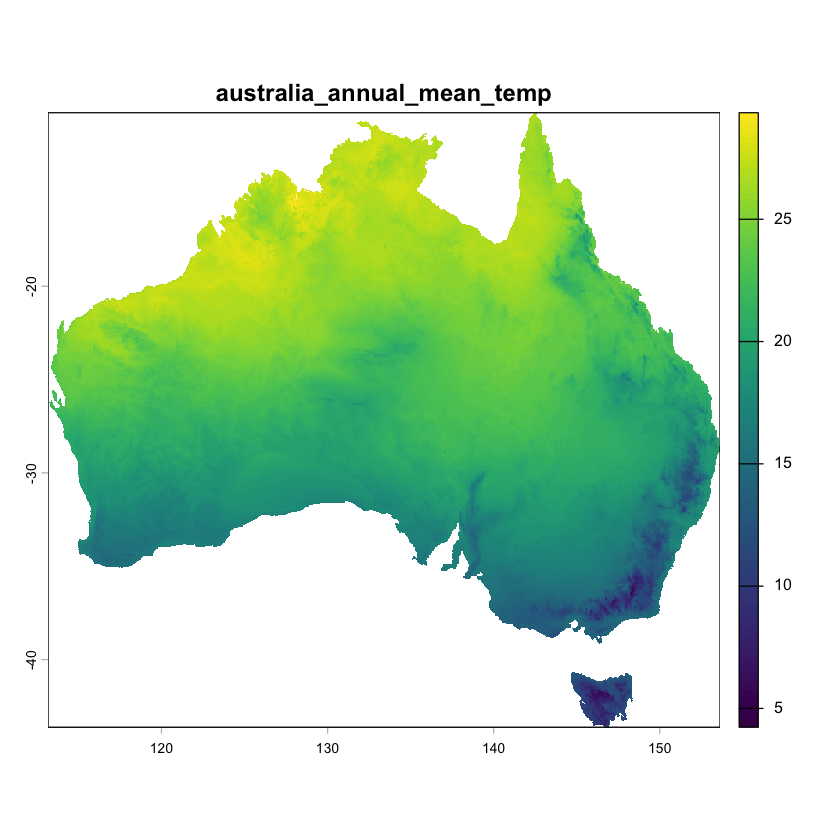

In [4]:

plot(input_raster, main = base_name)



# Step 5. Save GeoTIFF output

By default, the output is written to the same directory as the input ASCII file.


In [5]:

# Save .tif output file to the same folder as the original ASCII grid file
out_dir <- dirname(asc_file)

# Build the output file name - Keep the original file name and change only the extension
out_file  <- file.path(out_dir, paste0(base_name, "_converted.tif"))

# Write the raster to disk as a GeoTIFF file
writeRaster(
  input_raster,
  out_file,
  overwrite = TRUE,
  filetype = "GTiff"
)

cat("Raster written to:\n", out_file, "\n")


Raster written to:
 /Users/xiangzhaoqcif/dev/notebooks_zhaoxiangmax/notebooks/data/australia_annual_mean_temp_converted.tif 



# Step 6. Verify spatial metadata after writing GeoTIFF

Reload the written GeoTIFF and verify that key spatial metadata including CRS, spatial extent, and resolution have been preserved during conversion.


In [6]:
# Reload written file
written_raster <- rast(out_file)

# CRS check

# Extract CRS info for input
input_crs_info <- terra::crs(input_raster, describe = TRUE)
input_crs_name <- input_crs_info$name
input_epsg <- input_crs_info$code

# Extract CRS info for output
output_crs_info <- terra::crs(written_raster, describe = TRUE)
output_crs_name <- output_crs_info$name
output_epsg <- output_crs_info$code

cat("\nInput CRS name:", input_crs_name, "\n")
cat("Input EPSG code:", input_epsg, "\n")

cat("\nOutput CRS name:", output_crs_name, "\n")
cat("Output EPSG code:", output_epsg, "\n")

# Validate CRS
if (!same.crs(input_raster, written_raster)) {
  stop("❌ CRS mismatch detected after writing GeoTIFF.")
}

# Extent check
cat("\nInput extent:\n")
print(ext(input_raster))

cat("\nOutput extent:\n")
print(ext(written_raster))

if (!isTRUE(all.equal(ext(input_raster), ext(written_raster)))) {
  stop("❌ Extent mismatch detected after writing GeoTIFF.")
}

# Resolution check
cat("\nInput resolution:\n")
print(res(input_raster))

cat("\nOutput resolution:\n")
print(res(written_raster))

if (!isTRUE(all.equal(res(input_raster), res(written_raster)))) {
  stop("❌ Resolution mismatch detected after writing GeoTIFF.")
}

cat("\n✅ All spatial metadata successfully preserved during conversion.\n")




Input CRS name: WGS 84 (CRS84) 
Input EPSG code: CRS84 

Output CRS name: WGS 84 
Output EPSG code: 4326 

Input extent:
SpatExtent : 113.166666666667, 153.625000000324, -43.625, -10.70833333307 (xmin, xmax, ymin, ymax)

Output extent:
SpatExtent : 113.166666666667, 153.625000000324, -43.625, -10.70833333307 (xmin, xmax, ymin, ymax)

Input resolution:
[1] 0.04166667 0.04166667

Output resolution:
[1] 0.04166667 0.04166667

✅ All spatial metadata successfully preserved during conversion.



# Summary

This notebook demonstrated a simple, reproducible workflow for converting an ASCII grid (.asc) into a GeoTIFF (.tif) raster using the `terra` package in R, while explicitly verifying that key spatial metadata were preserved during conversion.

A companion notebook (link below) demonstrates the reverse workflow, converting a GeoTIFF (.tif) raster to ASCII grid (.asc) format.

[Converting Rasters from GeoTIFF (.tif) to ASCII (.asc) Format](https://ecocommonsaustralia.github.io/notebook-blog/notebooks/raster_format/converting_geotif_to_ascii_notebook.html)

![](https://raw.githubusercontent.com/EcoCommons-Australia-2024-2026/ec-notebook_site/main/images/EC_breaker_nobackgoundcolor.png)

EcoCommons received investment (<https://doi.org/10.3565/chbq-mr75>) from the Australian Research Data Commons (ARDC). The ARDC is enabled by the National Collaborative Research Infrastructure Strategy (NCRIS).


**Our Partners**


![](https://raw.githubusercontent.com/EcoCommons-Australia-2024-2026/ec-notebook_site/main/images/updated_ourpartner_2025.png)

## Other file formats of this notebook

| Notebook | Files | Open in Colab / ARDC Jupyter | DOI |
|:---:|:---:|:---:|:---:|
| Converting Rasters from ASCII (.asc) to GeoTIFF (.tif) Format | <a href="https://github.com/ecocommonsaustralia/notebooks/blob/main/notebooks/converting_ascii_to_geotiff_notebook.ipynb"><img src="https://github.com/ecocommonsaustralia/notebooks/raw/main/assets/jupyter_notebook.png" width="40%"></a>&nbsp;&nbsp;<a href="https://github.com/ecocommonsaustralia/notebooks/blob/main/notebooks/converting_ascii_to_geotiff_notebook.qmd"><img src="https://github.com/ecocommonsaustralia/notebooks/raw/main/assets/quartomd.png" width="40%"></a> | [![Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ecocommonsaustralia/notebooks/blob/main/notebooks/converting_ascii_to_geotiff_notebook.ipynb) | [![DOI](https://img.shields.io/badge/DOI-10.5281%2Fzenodo.19379605-blue)](https://doi.org/10.5281/zenodo.19379605) |

## How to cite this Notebook

Newis, R., & Zhao, X. Y. (2026). *Converting Rasters from ASCII (.asc) to GeoTIFF (.tif) Format* (Version 1.0) [Computational notebook]. Zenodo. <https://doi.org/10.5281/zenodo.19379605>

# How to Cite EcoCommons

If you use EcoCommons in your research, please cite the platform as follows:

> EcoCommons Australia 2026. *EcoCommons Australia – a collaborative commons for ecological and environmental modelling*, Queensland Cyber Infrastructure Foundation, Brisbane, Queensland. Available at: <https://data–explorer.app.ecocommons.org.au/> (Accessed: MM DD, YYYY). <https://doi.org/10.3565/chbq-mr75>

You can download the citation file for EcoCommons Australia here: [Download the BibTeX file](reference.bib)